In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import importlib
import numpy as np
from sklearn.datasets import make_blobs, make_circles, make_moons, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report



from models.Kernels import LinearKernel, RBFKernel
from models.SCS import StochasticConjugateSubgradientAlgorithm
from models.Pegasos import PegasosBaseline
from models.SGD import SGDBaseline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Helper functions

In [83]:
def plot_dataset(X, y, title="Dataset"): 
    plt.figure(figsize=(6,6)) 
    plt.scatter( X[y == -1, 0], X[y == -1, 1], label="-1" ) 
    plt.scatter( X[y == 1, 0], X[y == 1, 1], label="+1" ) 
    plt.title(title) 
    plt.legend() 
    plt.show()


def plot_decision_boundary(model, X, y, title="Decision Boundary"): 
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1 
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1 
    xx, yy = np.meshgrid( np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300) ) 
    grid = np.c_[xx.ravel(), yy.ravel()] 
    print(grid.shape)
    preds = model.predict(grid) 
    preds = preds.reshape(xx.shape) 
    plt.figure(figsize=(7,7)) 
    plt.contourf(xx, yy, preds, alpha=0.3) 
    plt.scatter( X[y == -1, 0], X[y == -1, 1], label="-1" ) 
    plt.scatter( X[y == 1, 0], X[y == 1, 1], label="+1" ) 
    plt.title(title) 
    plt.legend() 
    plt.show()

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model", fit_kwargs=None): 
    if fit_kwargs is None: 
        fit_kwargs = {}
    print(fit_kwargs)
    model.fit(X_train, y_train, **fit_kwargs) 
    train_preds = model.predict(X_train) 
    print("=======")
    test_preds = model.predict(X_test) 
    train_acc = accuracy_score(y_train, train_preds) 
    test_acc = accuracy_score(y_test, test_preds) 
    print(model_name) 
    print(f"Train accuracy: {train_acc:.4f}") 
    print(f"Test accuracy : {test_acc:.4f}") 
    print("\nClassification report:") 
    print(classification_report(y_test, test_preds)) 
    if (X_train.shape[1] == 2):
        plot_decision_boundary( model, X_train, y_train, title=f"{model_name} - decision boundary")

def plot_convergence(models, labels):
    plt.figure(figsize=(8,6))
    for model, label in zip(models, labels):
        plt.plot(
            model.history,
            label=label
        )
    plt.xlabel("Iteration")
    plt.ylabel("Objective value")
    plt.title("Convergence comparison")

    plt.legend()
    plt.show()

## Dataset 1 - blobs, linearly separable case

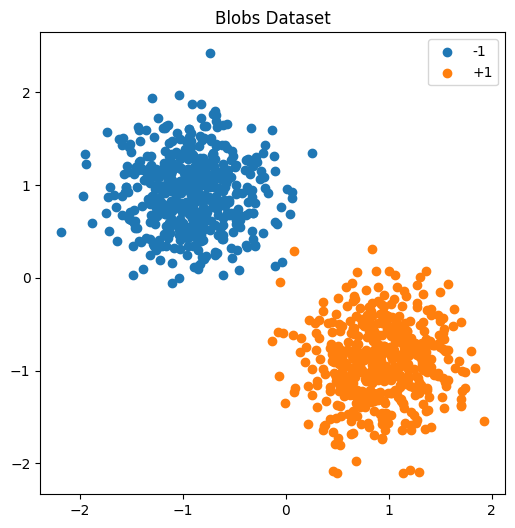

In [73]:
X, y = make_blobs(n_samples=1000, centers=2, cluster_std=1.5, random_state=42)
y = 2*y - 1

scaler = StandardScaler() 
X = scaler.fit_transform(X)

plot_dataset(X, y, "Blobs Dataset")

{'max_iter': 100, 'precompute_kernel': True}
SGD - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


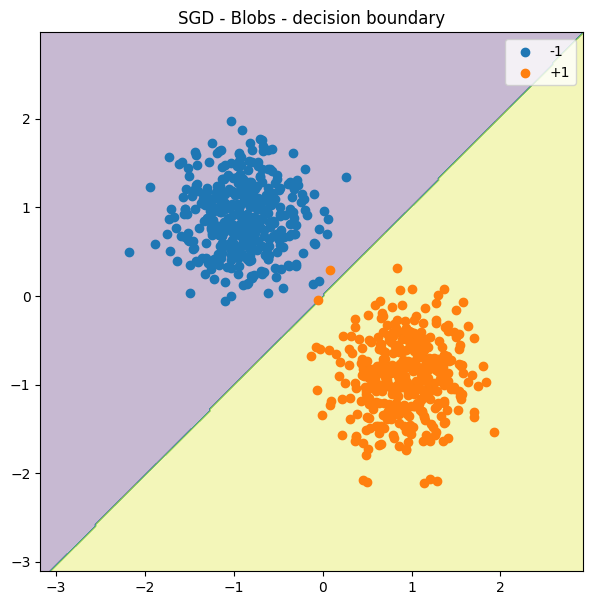

{'max_iter': 100, 'precompute_kernel': True}
Pegasos - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


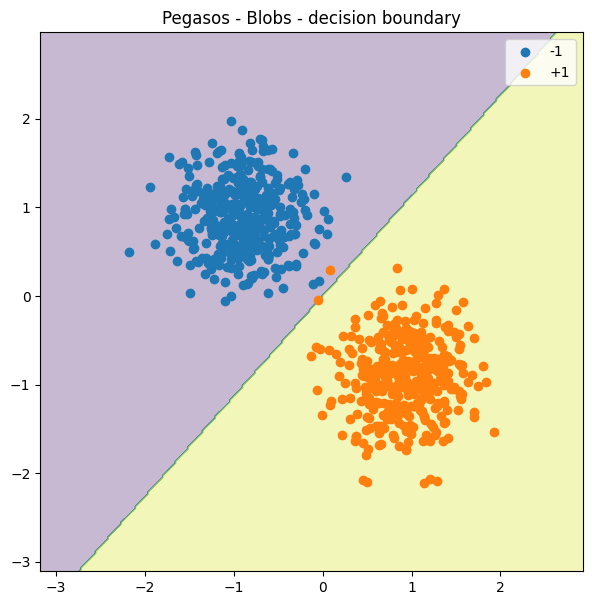

{'max_iter': 100, 'batch_size': 8}
Insufficient samples remaining to construct validation batch T_k.


c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:126: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:129: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:144: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


SCSG - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


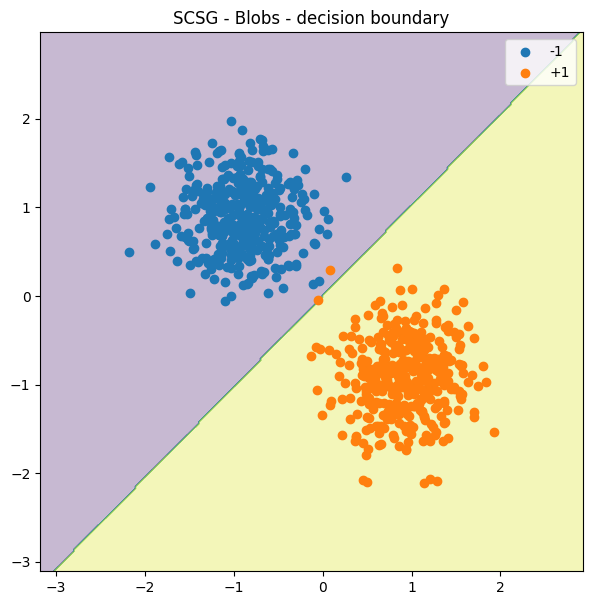

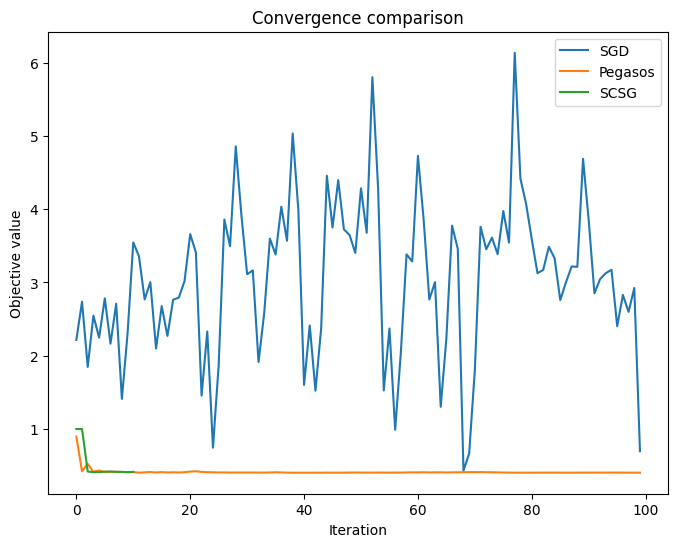

In [74]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
sgd_model = SGDBaseline(kernel=LinearKernel(), eta=0.001)
evaluate_model( sgd_model, X_train, X_test, y_train, y_test, model_name="SGD - Blobs", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

pegasos_model = PegasosBaseline(kernel=LinearKernel()) 
evaluate_model( pegasos_model, X_train, X_test, y_train, y_test, model_name="Pegasos - Blobs", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

scsg_model = StochasticConjugateSubgradientAlgorithm(kernel=LinearKernel()) 
evaluate_model(scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG - Blobs", fit_kwargs={ "max_iter": 100, "batch_size": 8 })


plot_convergence(
    [sgd_model, pegasos_model, scsg_model],
    ["SGD", "Pegasos", "SCSG"]
)

{'max_iter': 100, 'batch_size': 8}


c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:126: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:129: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:144: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


Insufficient samples remaining to construct validation batch T_k.
SCSG - Blobs
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       103
           1       1.00      1.00      1.00        97

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


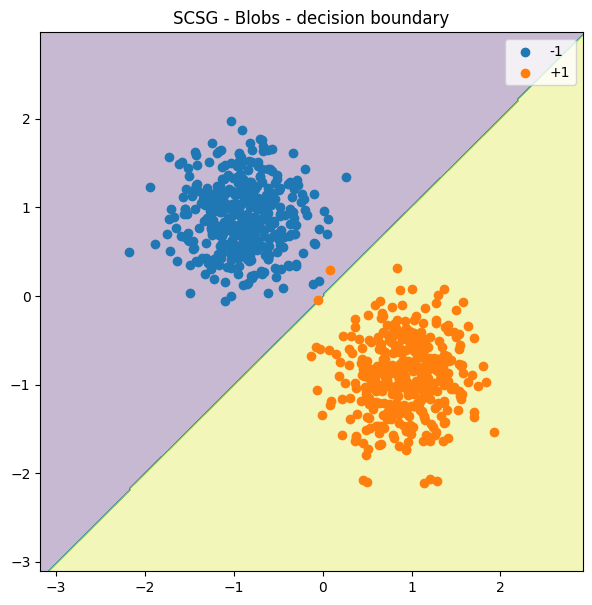

In [75]:
scsg_model = StochasticConjugateSubgradientAlgorithm(kernel=LinearKernel())
evaluate_model(scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG - Blobs", fit_kwargs={ "max_iter": 100, "batch_size": 8 })

## Dataset 2 - moons, not linearly separable case

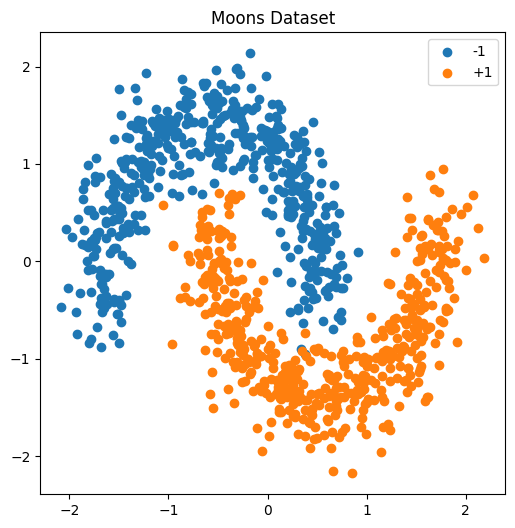

In [76]:
X, y = make_moons(n_samples=1000, noise=0.15, random_state=42 ) 
y = 2*y - 1

scaler = StandardScaler() 
X = scaler.fit_transform(X)

plot_dataset(X, y, "Moons Dataset")

{'max_iter': 100, 'precompute_kernel': True}
SGD Linear - Moons
Train accuracy: 0.8712
Test accuracy : 0.8550

Classification report:
              precision    recall  f1-score   support

          -1       0.86      0.85      0.85       100
           1       0.85      0.86      0.86       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200

(90000, 2)


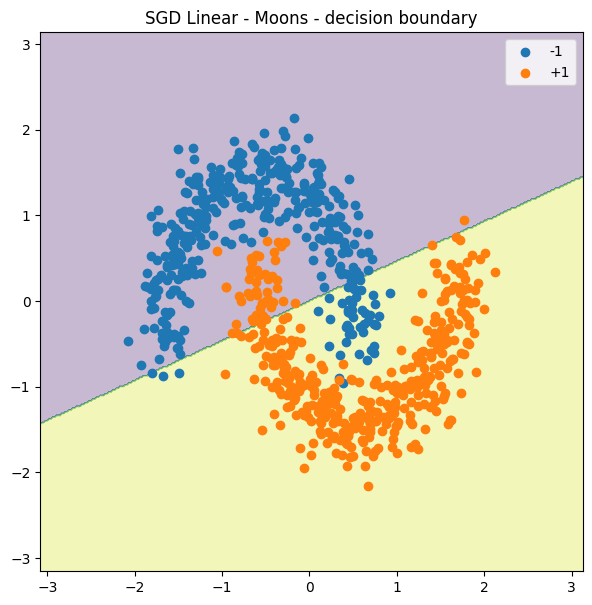

{'max_iter': 100, 'precompute_kernel': True}
SGD RBF - Moons
Train accuracy: 0.9600
Test accuracy : 0.9700

Classification report:
              precision    recall  f1-score   support

          -1       0.97      0.97      0.97       100
           1       0.97      0.97      0.97       100

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

(90000, 2)


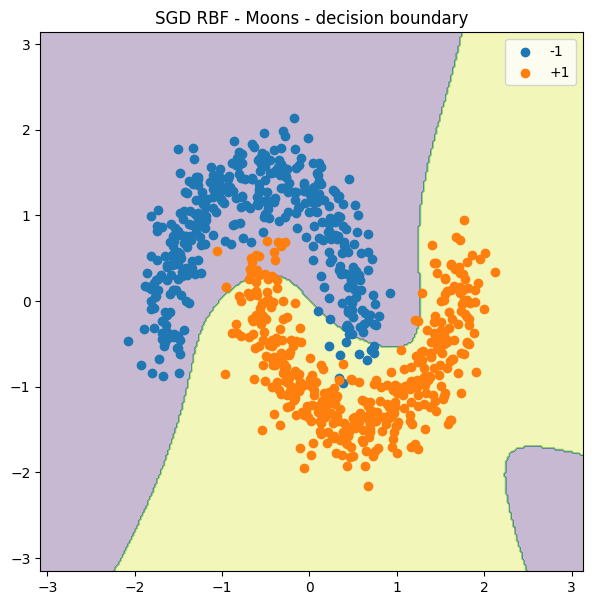

{'max_iter': 100, 'precompute_kernel': True}
Pegasos RBF - Moons
Train accuracy: 0.9600
Test accuracy : 0.9650

Classification report:
              precision    recall  f1-score   support

          -1       0.95      0.98      0.97       100
           1       0.98      0.95      0.96       100

    accuracy                           0.96       200
   macro avg       0.97      0.96      0.96       200
weighted avg       0.97      0.96      0.96       200

(90000, 2)


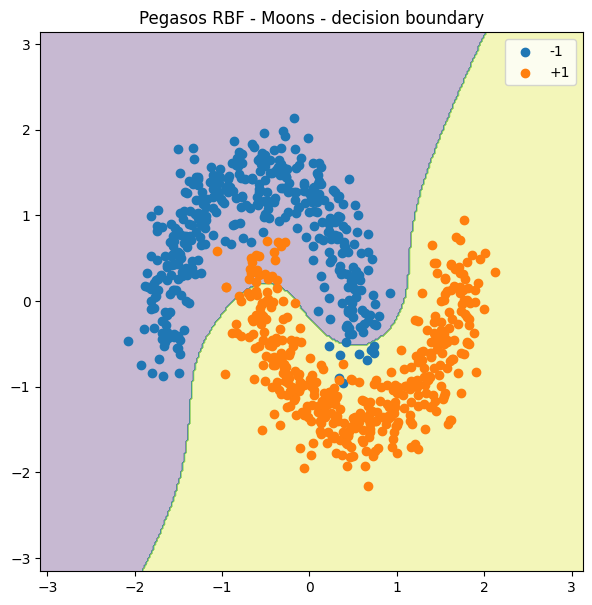

{'max_iter': 100, 'batch_size': 8}


c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:126: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:129: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:144: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


Insufficient samples remaining to construct validation batch T_k.
SCSG RBF - Moons
Train accuracy: 0.9537
Test accuracy : 0.9600

Classification report:
              precision    recall  f1-score   support

          -1       0.99      0.93      0.96       100
           1       0.93      0.99      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200

(90000, 2)


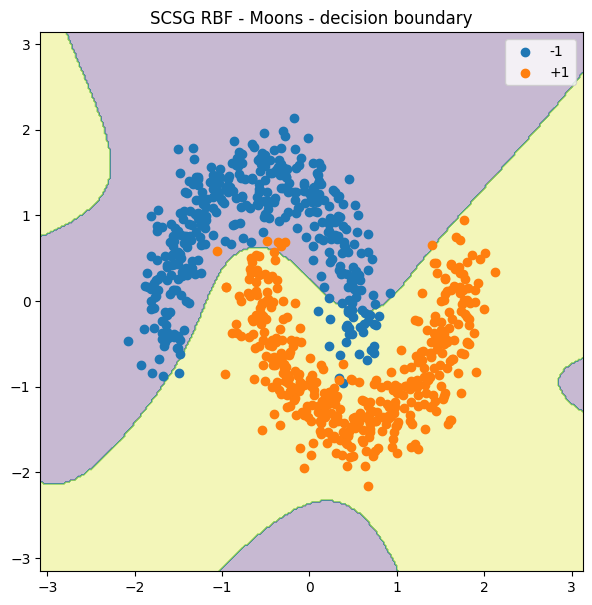

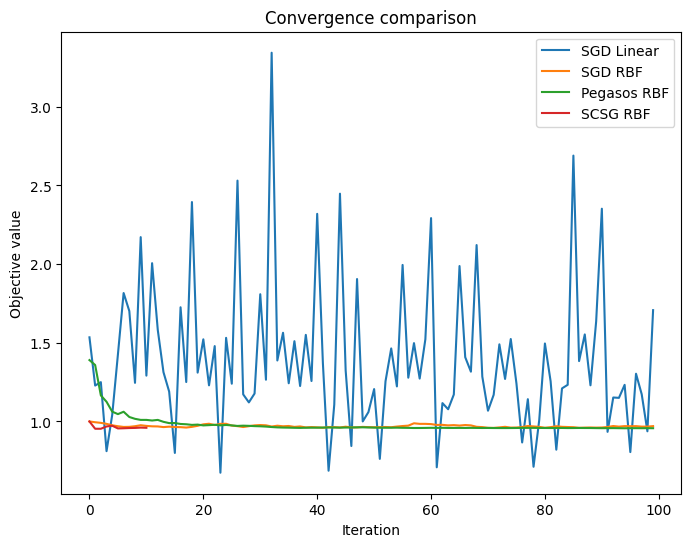

In [77]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

sgd_model_linear = SGDBaseline( kernel=LinearKernel(), eta=0.001)
evaluate_model( sgd_model_linear, X_train, X_test, y_train, y_test, model_name="SGD Linear - Moons", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

sgd_model_rbf = SGDBaseline( kernel=RBFKernel(gamma_rbf=2.0), eta=0.001)
evaluate_model( sgd_model_rbf, X_train, X_test, y_train, y_test, model_name="SGD RBF - Moons", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

pegasos_model = PegasosBaseline( kernel=RBFKernel(gamma_rbf=2.0))
evaluate_model( pegasos_model, X_train, X_test, y_train, y_test, model_name="Pegasos RBF - Moons", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

scsg_model = StochasticConjugateSubgradientAlgorithm( kernel=RBFKernel(gamma_rbf=2.0))
evaluate_model( scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG RBF - Moons", fit_kwargs={ "max_iter": 100, "batch_size": 8 })

plot_convergence(
    [sgd_model_linear, sgd_model_rbf, pegasos_model, scsg_model],
    ["SGD Linear", "SGD RBF", "Pegasos RBF", "SCSG RBF"]
)

## Dataset 3 - circles

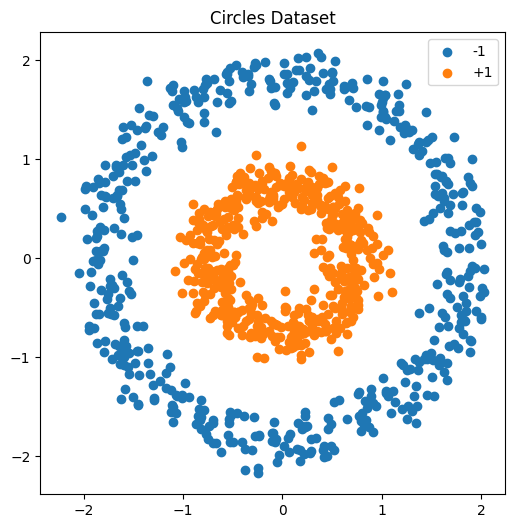

In [78]:
X, y = make_circles( n_samples=1000, factor=0.4, noise=0.08, random_state=42 ) 
y = 2*y - 1

scaler = StandardScaler()
X = scaler.fit_transform(X)

plot_dataset(X, y, "Circles Dataset")

{'max_iter': 100, 'precompute_kernel': True}
SGD RBF - Circles
Train accuracy: 0.9962
Test accuracy : 0.9950

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.99      0.99       100
           1       0.99      1.00      1.00       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

(90000, 2)


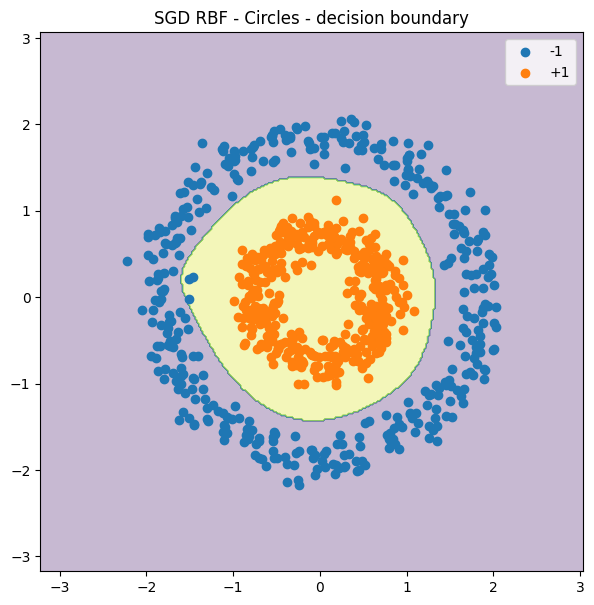

{'max_iter': 100, 'precompute_kernel': True}
Pegasos RBF - Circles
Train accuracy: 0.9975
Test accuracy : 1.0000

Classification report:
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

(90000, 2)


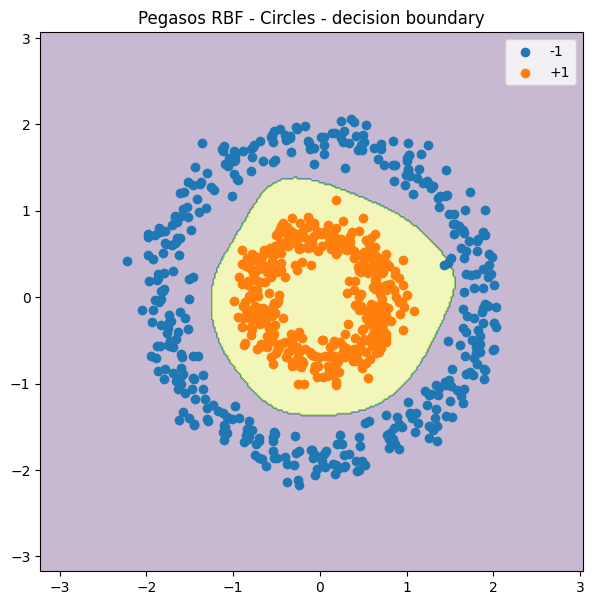

{'max_iter': 100, 'batch_size': 8}
Insufficient samples remaining to construct validation batch T_k.


c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:126: RuntimeWarning: invalid value encountered in multiply
  alpha_new=alpha+step_t*d
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:129: RuntimeWarning: invalid value encountered in scalar multiply
  int_L=(f_new-f_val)<=-self.m1*np.dot(d,d)*step_t
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:144: RuntimeWarning: invalid value encountered in scalar multiply
  if t*norm_d >delta_k:
c:\Users\basiu\OneDrive\Pulpit\sem 8\optimization\Stochastic_Conjugete_subgradient_algorithm_for_kernel_SVM\models\SCS.py:56: RuntimeWarning: invalid value encountered in multiply
  alpha_hat_new=alpha_hat+t_k*d_vec


SCSG RBF - Circles
Train accuracy: 0.8725
Test accuracy : 0.8900

Classification report:
              precision    recall  f1-score   support

          -1       1.00      0.78      0.88       100
           1       0.82      1.00      0.90       100

    accuracy                           0.89       200
   macro avg       0.91      0.89      0.89       200
weighted avg       0.91      0.89      0.89       200

(90000, 2)


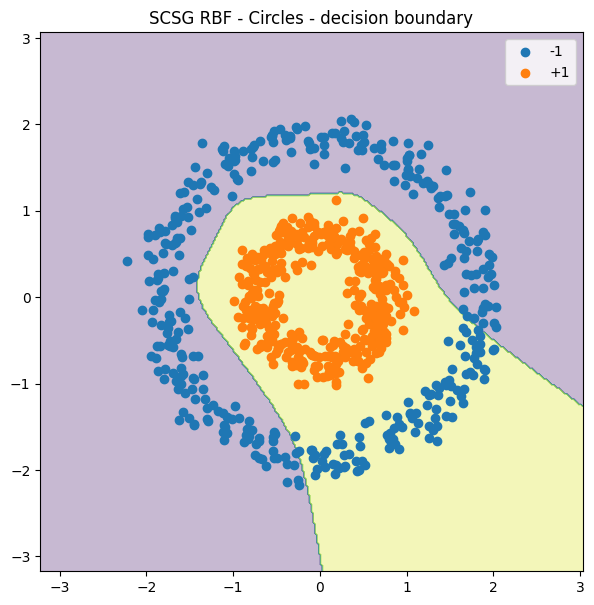

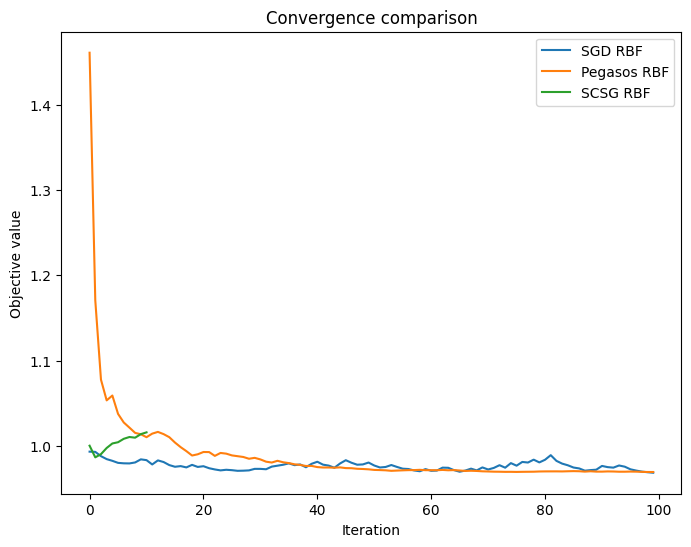

In [79]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
gamma = 3.0

sgd_model_rbf = SGDBaseline( kernel=RBFKernel(gamma_rbf=gamma), eta=0.001)
evaluate_model( sgd_model_rbf, X_train, X_test, y_train, y_test, model_name="SGD RBF - Circles", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

pegasos_model = PegasosBaseline( kernel=RBFKernel(gamma_rbf=gamma))
evaluate_model( pegasos_model, X_train, X_test, y_train, y_test, model_name="Pegasos RBF - Circles", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })

scsg_model = StochasticConjugateSubgradientAlgorithm( kernel=RBFKernel(gamma_rbf=gamma))
evaluate_model( scsg_model, X_train, X_test, y_train, y_test, model_name="SCSG RBF - Circles", fit_kwargs={ "max_iter": 100, "batch_size": 8 })

plot_convergence(
    [sgd_model_rbf, pegasos_model, scsg_model],
    ["SGD RBF", "Pegasos RBF", "SCSG RBF"]
)


In [80]:
shapes=[]
for x_test in X_test:
    shapes.append(x_test.shape[0])
arr=np.array(shapes)
np.unique(arr)

array([2])

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
y = 2*y - 1

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

sgd_model_linear = SGDBaseline( kernel=LinearKernel(), eta=0.001)
evaluate_model( sgd_model_linear, X_train, X_test, y_train, y_test, model_name="SGD Linear - Breast Cancer", fit_kwargs={ "max_iter": 100, "precompute_kernel": True })



{'max_iter': 100, 'precompute_kernel': True}
SGD Linear - Breast Cancer
Train accuracy: 0.0967
Test accuracy : 0.0439

Classification report:
              precision    recall  f1-score   support

          -1       0.03      0.05      0.04        43
           1       0.07      0.04      0.05        71

    accuracy                           0.04       114
   macro avg       0.05      0.04      0.04       114
weighted avg       0.05      0.04      0.05       114

